<a href="https://colab.research.google.com/github/mayur07699/MLDS/blob/main/Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [3]:
df = pd.read_csv('/content/IPLPlayerStat-1.csv')

In [4]:
df

,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,600,Yash Dayal,0,0,1,11.0,205.0,296.0,9,0.00,0.00,0.00,8.66,26.91,18.64,1.0,0.0
601,601,Yashpal Singh,47,5,67,0.0,0.0,0.0,4,11.75,70.15,7.46,0.00,0.00,0.00,3.0,0.0
602,602,Younis Khan,3,0,7,0.0,0.0,0.0,1,3.00,42.86,0.00,0.00,0.00,0.00,1.0,0.0
603,603,Yuvraj Singh,2754,367,2207,36.0,882.0,1091.0,129,21.35,124.78,16.63,7.42,30.31,24.50,29.0,0.0


In [5]:
df.head()

,Unnamed: 0,player,runs,boundaries,balls_faced,wickets,balls_bowled,runs_conceded,matches,batting_avg,batting_strike_rate,boundaries_percent,bowling_economy,bowling_avg,bowling_strike_rate,catches,stumpings
0,0,A Ashish Reddy,280,31,196,18.0,270.0,400.0,28,10.00,142.86,15.82,8.89,22.22,15.00,8.0,0.0
1,1,A Badoni,161,18,139,2.0,12.0,12.0,11,14.64,115.83,12.95,6.00,6.00,6.00,8.0,0.0
2,2,A Chandila,4,0,7,11.0,234.0,245.0,12,0.33,57.14,0.00,6.28,22.27,21.27,2.0,0.0
3,3,A Chopra,53,7,75,0.0,0.0,0.0,6,8.83,70.67,9.33,0.00,0.00,0.00,2.0,0.0
4,4,A Choudhary,25,2,20,5.0,108.0,144.0,5,5.00,125.00,10.00,8.00,28.80,21.60,0.0,0.0


In [6]:
df.shape

(605, 17)

In [7]:
df['runs'].describe()

,runs
count,605.000000
mean,464.428099
std,985.272855
min,0.000000
25%,15.000000
50%,73.000000
75%,326.000000
max,6634.000000


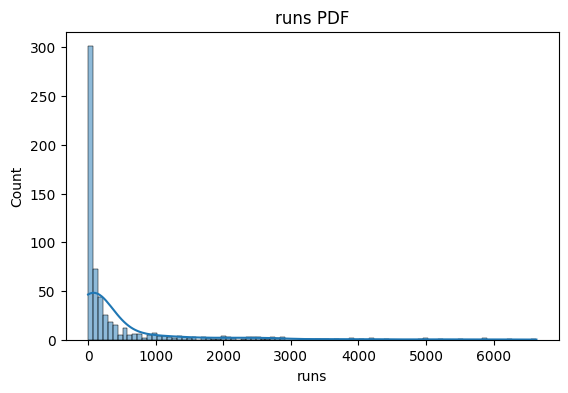

In [10]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(df["runs"], kde=True)
plt.title('runs PDF')
plt.show()

In [15]:
df["runs_log"]= np.log1p(df["runs"])
df["runs_log10"]=df["runs_log"]/np.log(10)
df[["runs","runs_log","runs_log10"]].head(10)

,runs,runs_log,runs_log10
0,280,5.638355,2.448706
1,161,5.087596,2.209515
2,4,1.609438,0.698970
3,53,3.988984,1.732394
4,25,3.258097,1.414973
5,4,1.609438,0.698970
6,62,4.143135,1.799341
7,35,3.583519,1.556303
8,108,4.691348,2.037426
9,362,5.894403,2.559907


Text(0.5, 1.0, 'runs PDF')

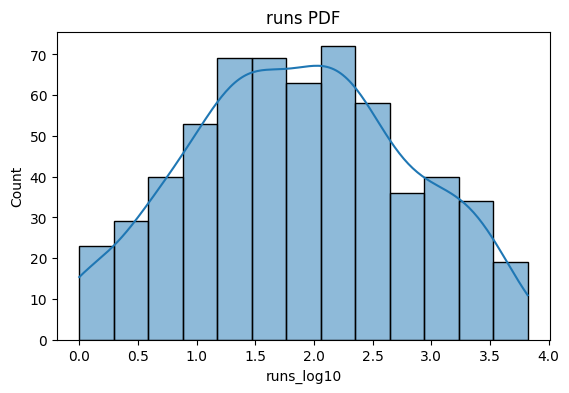

In [17]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.histplot(df["runs_log10"],kde=True)
plt.title('runs PDF')

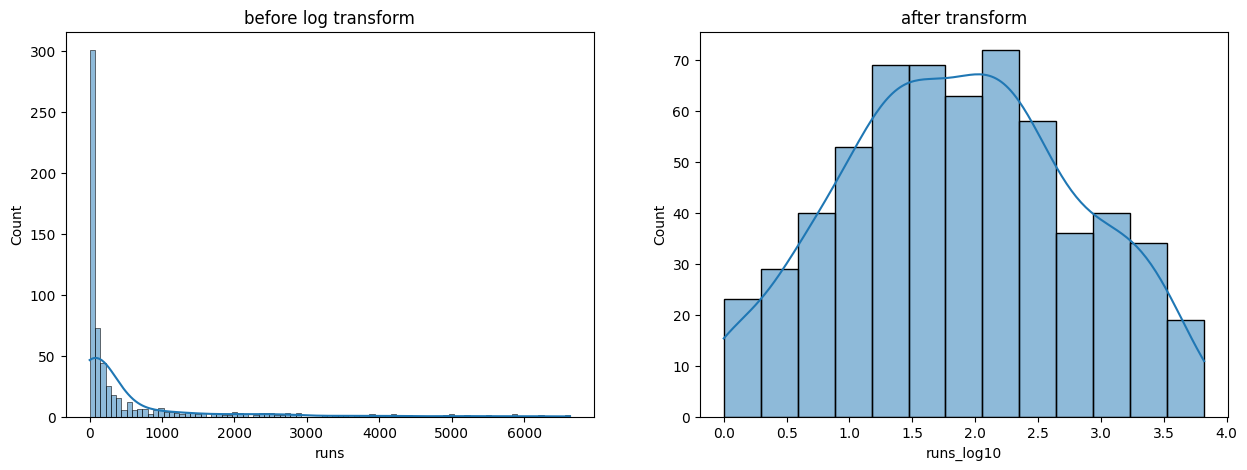

In [18]:
fig , ax = plt.subplots(1,2,figsize=(15,5))
sns.histplot(df["runs"],kde = True,ax=ax[0])
ax[0].set_title("before log transform")
sns.histplot(df["runs_log10"],kde = True,ax=ax[1])
ax[1].set_title("after transform")
plt.show()

In [20]:
#powertransform
from sklearn.preprocessing import PowerTransformer

In [21]:
df['matches'].describe()

,matches
count,605.000000
mean,32.869421
std,42.215050
min,1.000000
25%,6.000000
50%,14.000000
75%,43.000000
max,221.000000


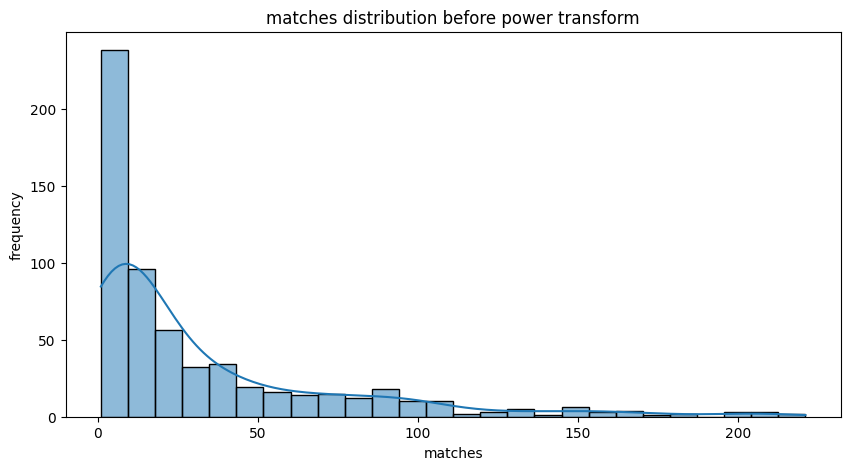

In [27]:
plt.figure(figsize=(10,5))
sns.histplot(df["matches"],kde= True)
plt.title("matches distribution before power transform")
plt.xlabel("matches")
plt.ylabel("frequency")
plt.show()

In [28]:
pt= PowerTransformer(method="yeo-johnson")
df["matches_power"]= pt.fit_transform(df[["matches"]].astype(int))
print(pt.lambdas_)

[-0.04910143]


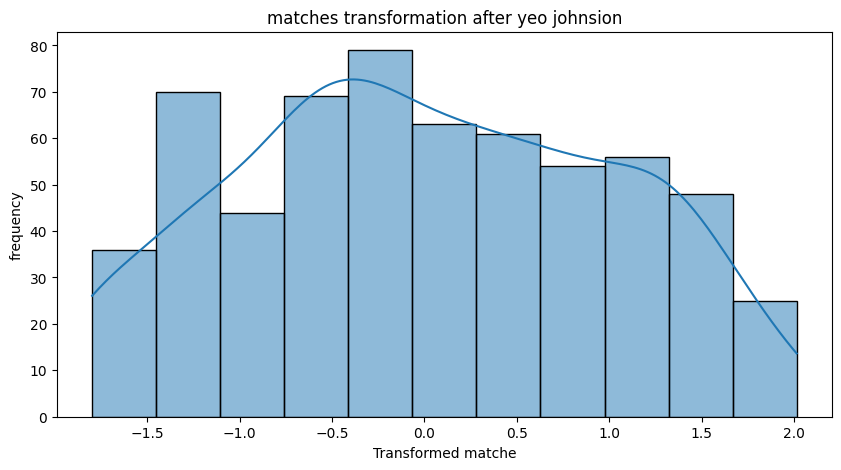

In [34]:
plt.figure(figsize=(10,5))
sns.histplot(df["matches_power"], kde=True)
plt.title("matches transformation after yeo johnsion")
plt.xlabel("Transformed matche")
plt.ylabel("frequency")
plt.show()

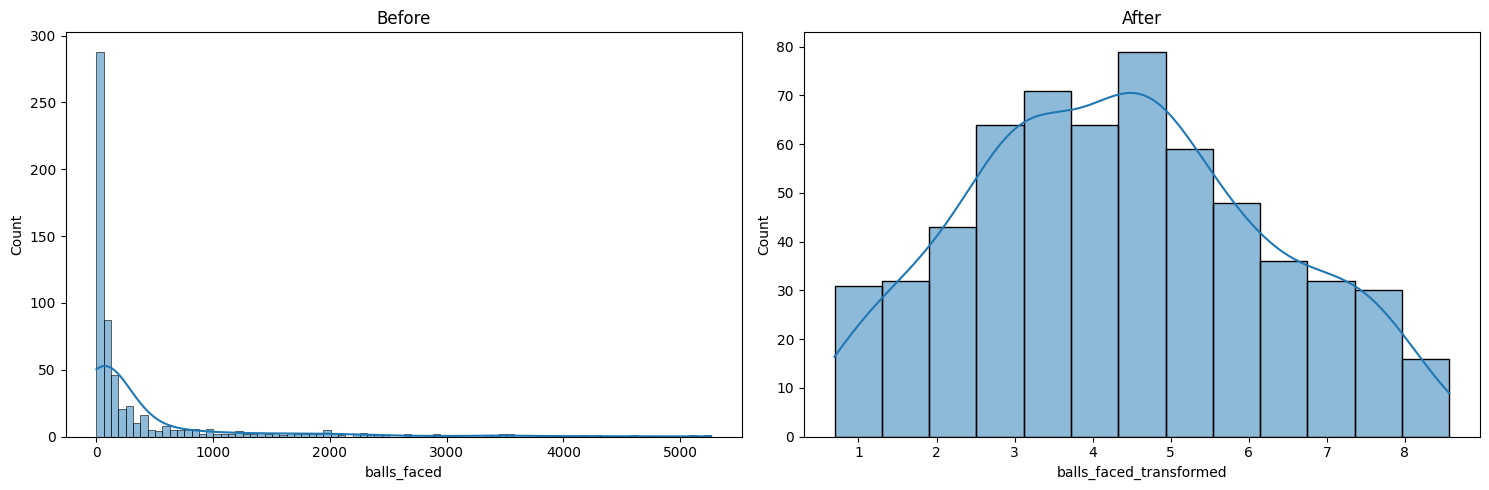

In [43]:
import numpy as np

df["balls_faced_transformed"] = np.log1p(df["balls_faced"])


fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df["balls_faced"], kde=True, ax=ax[0])
ax[0].set_title("Before")

sns.histplot(df["balls_faced_transformed"], kde=True, ax=ax[1])
ax[1].set_title("After")

plt.tight_layout()
plt.show()

In [39]:
print(df.columns.tolist())

['Unnamed: 0', 'player', 'runs', 'boundaries', 'balls_faced', 'wickets', 'balls_bowled', 'runs_conceded', 'matches', 'batting_avg', 'batting_strike_rate', 'boundaries_percent', 'bowling_economy', 'bowling_avg', 'bowling_strike_rate', 'catches', 'stumpings', 'runs_log', 'runs_log10', 'matches_power']


In [41]:
import numpy as np

df["balls_faced_transformed"] = np.log1p(df["balls_faced"])

print(df.columns)
print(df[["balls_faced", "balls_faced_transformed"]].head())

Index(['Unnamed: 0', 'player', 'runs', 'boundaries', 'balls_faced', 'wickets',
       'balls_bowled', 'runs_conceded', 'matches', 'batting_avg',
       'batting_strike_rate', 'boundaries_percent', 'bowling_economy',
       'bowling_avg', 'bowling_strike_rate', 'catches', 'stumpings',
       'runs_log', 'runs_log10', 'matches_power', 'balls_faced_transformed'],
      dtype='object')
   balls_faced  balls_faced_transformed
0          196                 5.283204
1          139                 4.941642
2            7                 2.079442
3           75                 4.330733
4           20                 3.044522


In [44]:
df = pd.read_csv("/content/class_ipl_22-26_dataset.csv")

In [45]:
df

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,win_by_wickets,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players
0,26-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,131,5,...,6,UT Yadav,M Nayyar,AK Chaudhary,Nitin Menon,VK Sharma,Chirra Ravikanthreddy,20,"RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ...","AM Rahane, VR Iyer, N Rana, SS Iyer, SW Billin..."
1,27-03-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,Delhi Capitals,field,177,5,...,4,Kuldeep Yadav,Prakash Bhatt,RJ Tucker,HAS Khalid,J Madanagopal,N Pandit,20,"RG Sharma, Ishan Kishan, Anmolpreet Singh, Til...","PP Shaw, TL Seifert, Mandeep Singh, RR Pant, L..."
2,27-03-2022,2022,Mumbai,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bangalore,Punjab Kings,Punjab Kings,field,205,2,...,5,OF Smith,M Nayyar,Nitin Menon,YC Barde,AK Chaudhary,R Pandit,20,"F du Plessis, Anuj Rawat, V Kohli, KD Karthik,...","MA Agarwal, S Dhawan, PBB Rajapaksa, LS Living..."
3,28-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,Gujarat Titans,field,158,6,...,5,Mohammed Shami,DS Manohar,PG Pathak,VK Sharma,RJ Tucker,GR Sadashiv Iyer,20,"KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ Ho...","Shubman Gill, MS Wade, V Shankar, HH Pandya, D..."
4,29-03-2022,2022,Pune,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,210,6,...,0,SV Samson,Shakti Singh,BNJ Oxenford,UV Gandhe,KN Ananthapadmanabhan,MV Saidharshan Kumar,20,"JC Buttler, YBK Jaiswal, SV Samson, D Padikkal...","KS Williamson, Abhishek Sharma, RA Tripathi, N..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,24-05-2026,2026,Kolkata,"Eden Gardens, Kolkata",Delhi Capitals,Kolkata Knight Riders,Kolkata Knight Riders,field,203,5,...,0,Kuldeep Yadav,IR Siddiqui,K Swaroopanand,HAS Khalid,SJ Nogajski,M Krishnadas,20,"Kuldeep Yadav, Abishek Porel, KL Rahul, SU Par...","SP Narine, AM Rahane, FH Allen, MK Pandey, C G..."
363,26-05-2026,2026,Dharamsala,"Himachal Pradesh Cricket Association Stadium, ...",Royal Challengers Bengaluru,Gujarat Titans,Gujarat Titans,field,254,5,...,0,RM Patidar,J Srinath,J Madanagopal,VK Sharma,Nitin Menon,KN Ananthapadmanabhan,20,"R Shepherd, VR Iyer, V Kohli, D Padikkal, RM P...","K Khejroliya, B Sai Sudharsan, Shubman Gill, J..."
364,27-05-2026,2026,New Chandigarh,Maharaja Yadavindra Singh International Cricke...,Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,243,8,...,0,V Suryavanshi,V Narayan Kutty,AT Holdstock,UV Gandhe,R Pandit,SJ Nogajski,20,"YBK Jaiswal, V Suryavanshi, Dhruv Jurel, R Par...","PP Hinge, Abhishek Sharma, TM Head, Ishan Kish..."
365,29-05-2026,2026,New Chandigarh,Maharaja Yadavindra Singh International Cricke...,Rajasthan Royals,Gujarat Titans,Rajasthan Royals,bat,214,6,...,7,Shubman Gill,Prakash Bhatt,R Pandit,SJ Nogajski,AT Holdstock,UV Gandhe,20,"TU Deshpande, YBK Jaiswal, V Suryavanshi, Dhru...","Mohammed Siraj, B Sai Sudharsan, Shubman Gill,..."


In [46]:
X = df[['team1_runs']]
X.head()

,team1_runs
0,131
1,177
2,205
3,158
4,210


In [49]:
bins = [0,120,160,200, df['team1_runs'].max()]
labels= ['low','Medium','High','Very High']
df['Runs_Category']= pd.cut(df['team1_runs'],
                            bins=bins,
                            labels = labels,
                            include_lowest =True
)
df[['team1_runs','Runs_Category']].head(10)

,team1_runs,Runs_Category
0,131,Medium
1,177,High
2,205,Very High
3,158,Medium
4,210,Very High
5,128,Medium
6,210,Very High
7,137,Medium
8,171,High
9,193,High


In [50]:
df['Runs_Category'].value_counts().sort_index()

,count
Runs_Category,
low,13
Medium,77
High,148
Very High,129


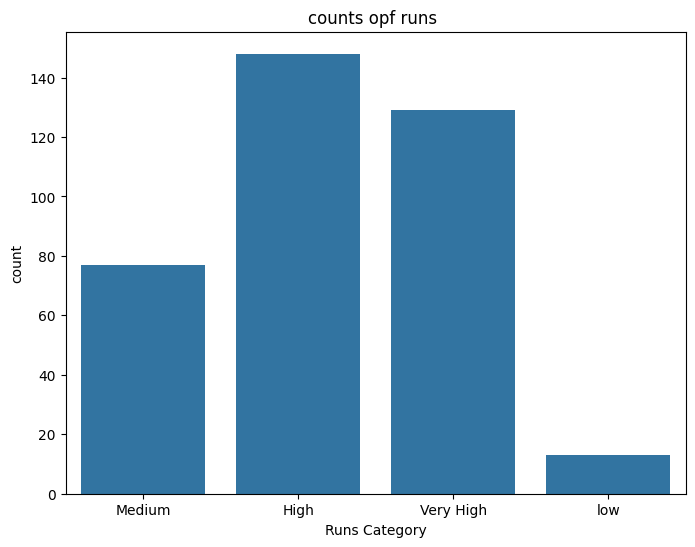

In [52]:
plt.figure(figsize=(8,6))
sns.countplot(x ='Runs_Category',data = df, order=df['Runs_Category'])
plt.title("counts opf runs ")
plt.xlabel('Runs Category')
plt.ylabel('count')
plt.show()

In [53]:
comparison = df[['team1_runs','Runs_Category']]
comparison.head(15)

,team1_runs,Runs_Category
0,131,Medium
1,177,High
2,205,Very High
3,158,Medium
4,210,Very High
5,128,Medium
6,210,Very High
7,137,Medium
8,171,High
9,193,High


In [54]:
#Binarization
from sklearn.preprocessing import Binarizer
df.head()

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players,Runs_Category
0,26-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,131,5,...,UT Yadav,M Nayyar,AK Chaudhary,Nitin Menon,VK Sharma,Chirra Ravikanthreddy,20,"RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ...","AM Rahane, VR Iyer, N Rana, SS Iyer, SW Billin...",Medium
1,27-03-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,Delhi Capitals,field,177,5,...,Kuldeep Yadav,Prakash Bhatt,RJ Tucker,HAS Khalid,J Madanagopal,N Pandit,20,"RG Sharma, Ishan Kishan, Anmolpreet Singh, Til...","PP Shaw, TL Seifert, Mandeep Singh, RR Pant, L...",High
2,27-03-2022,2022,Mumbai,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bangalore,Punjab Kings,Punjab Kings,field,205,2,...,OF Smith,M Nayyar,Nitin Menon,YC Barde,AK Chaudhary,R Pandit,20,"F du Plessis, Anuj Rawat, V Kohli, KD Karthik,...","MA Agarwal, S Dhawan, PBB Rajapaksa, LS Living...",Very High
3,28-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,Gujarat Titans,field,158,6,...,Mohammed Shami,DS Manohar,PG Pathak,VK Sharma,RJ Tucker,GR Sadashiv Iyer,20,"KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ Ho...","Shubman Gill, MS Wade, V Shankar, HH Pandya, D...",Medium
4,29-03-2022,2022,Pune,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,210,6,...,SV Samson,Shakti Singh,BNJ Oxenford,UV Gandhe,KN Ananthapadmanabhan,MV Saidharshan Kumar,20,"JC Buttler, YBK Jaiswal, SV Samson, D Padikkal...","KS Williamson, Abhishek Sharma, RA Tripathi, N...",Very High


In [55]:
X = df[['team1_runs']]
X.head()

,team1_runs
0,131
1,177
2,205
3,158
4,210


In [56]:
binarizer = Binarizer(threshold=160)

In [60]:
X_binary = binarizer.fit_transform(X)
X_binary = pd.DataFrame(X_binary,columns =['team1_runs'])
X_binary.head()

,team1_runs
0,0
1,1
2,1
3,0
4,1


In [62]:
comparison = pd.DataFrame({
    'Original': X['team1_runs'],
    'Binarizer': X_binary['team1_runs']
})
comparison.head()

,Original,Binarizer
0,131,0
1,177,1
2,205,1
3,158,0
4,210,1


In [64]:
comparison ['Binarizer'].value_counts()

,count
Binarizer,
1,277
0,90


/tmp/ipykernel_595/2439495802.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'team1_runs',data = X_binary,palette='viridis')


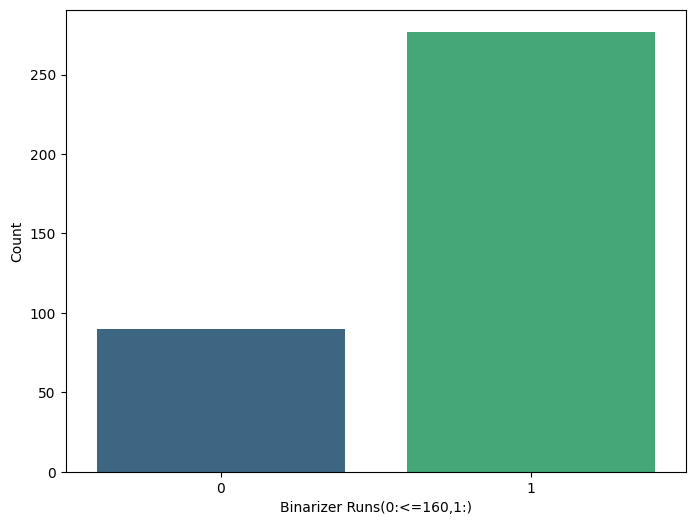

In [66]:
plt.figure(figsize=(8,6))
sns.countplot(x = 'team1_runs',data = X_binary,palette='viridis')

plt.xlabel('Binarizer Runs(0:<=160,1:)')
plt.ylabel('Count')
plt.xticks(ticks=[0,1], labels =['0','1'])
plt.show()

In [67]:
#ColumnsTransformer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


In [68]:
df

,date,season,city,venue,team1,team2,toss_winner,toss_decision,team1_runs,team1_wickets,...,player_of_match,match_referee,umpire1,umpire2,tv_umpire,reserve_umpire,overs_limit,team1_players,team2_players,Runs_Category
0,26-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,field,131,5,...,UT Yadav,M Nayyar,AK Chaudhary,Nitin Menon,VK Sharma,Chirra Ravikanthreddy,20,"RD Gaikwad, DP Conway, RV Uthappa, AT Rayudu, ...","AM Rahane, VR Iyer, N Rana, SS Iyer, SW Billin...",Medium
1,27-03-2022,2022,Mumbai,"Brabourne Stadium, Mumbai",Mumbai Indians,Delhi Capitals,Delhi Capitals,field,177,5,...,Kuldeep Yadav,Prakash Bhatt,RJ Tucker,HAS Khalid,J Madanagopal,N Pandit,20,"RG Sharma, Ishan Kishan, Anmolpreet Singh, Til...","PP Shaw, TL Seifert, Mandeep Singh, RR Pant, L...",High
2,27-03-2022,2022,Mumbai,"Dr DY Patil Sports Academy, Mumbai",Royal Challengers Bangalore,Punjab Kings,Punjab Kings,field,205,2,...,OF Smith,M Nayyar,Nitin Menon,YC Barde,AK Chaudhary,R Pandit,20,"F du Plessis, Anuj Rawat, V Kohli, KD Karthik,...","MA Agarwal, S Dhawan, PBB Rajapaksa, LS Living...",Very High
3,28-03-2022,2022,Mumbai,"Wankhede Stadium, Mumbai",Lucknow Super Giants,Gujarat Titans,Gujarat Titans,field,158,6,...,Mohammed Shami,DS Manohar,PG Pathak,VK Sharma,RJ Tucker,GR Sadashiv Iyer,20,"KL Rahul, Q de Kock, E Lewis, MK Pandey, DJ Ho...","Shubman Gill, MS Wade, V Shankar, HH Pandya, D...",Medium
4,29-03-2022,2022,Pune,"Maharashtra Cricket Association Stadium, Pune",Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,210,6,...,SV Samson,Shakti Singh,BNJ Oxenford,UV Gandhe,KN Ananthapadmanabhan,MV Saidharshan Kumar,20,"JC Buttler, YBK Jaiswal, SV Samson, D Padikkal...","KS Williamson, Abhishek Sharma, RA Tripathi, N...",Very High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,24-05-2026,2026,Kolkata,"Eden Gardens, Kolkata",Delhi Capitals,Kolkata Knight Riders,Kolkata Knight Riders,field,203,5,...,Kuldeep Yadav,IR Siddiqui,K Swaroopanand,HAS Khalid,SJ Nogajski,M Krishnadas,20,"Kuldeep Yadav, Abishek Porel, KL Rahul, SU Par...","SP Narine, AM Rahane, FH Allen, MK Pandey, C G...",Very High
363,26-05-2026,2026,Dharamsala,"Himachal Pradesh Cricket Association Stadium, ...",Royal Challengers Bengaluru,Gujarat Titans,Gujarat Titans,field,254,5,...,RM Patidar,J Srinath,J Madanagopal,VK Sharma,Nitin Menon,KN Ananthapadmanabhan,20,"R Shepherd, VR Iyer, V Kohli, D Padikkal, RM P...","K Khejroliya, B Sai Sudharsan, Shubman Gill, J...",Very High
364,27-05-2026,2026,New Chandigarh,Maharaja Yadavindra Singh International Cricke...,Rajasthan Royals,Sunrisers Hyderabad,Sunrisers Hyderabad,field,243,8,...,V Suryavanshi,V Narayan Kutty,AT Holdstock,UV Gandhe,R Pandit,SJ Nogajski,20,"YBK Jaiswal, V Suryavanshi, Dhruv Jurel, R Par...","PP Hinge, Abhishek Sharma, TM Head, Ishan Kish...",Very High
365,29-05-2026,2026,New Chandigarh,Maharaja Yadavindra Singh International Cricke...,Rajasthan Royals,Gujarat Titans,Rajasthan Royals,bat,214,6,...,Shubman Gill,Prakash Bhatt,R Pandit,SJ Nogajski,AT Holdstock,UV Gandhe,20,"TU Deshpande, YBK Jaiswal, V Suryavanshi, Dhru...","Mohammed Siraj, B Sai Sudharsan, Shubman Gill,...",Very High


In [69]:
 X = df[['team1_runs', 'toss_decision','team1_wickets','win_by_wickets']]
 X.head()

,team1_runs,toss_decision,team1_wickets,win_by_wickets
0,131,field,5,6
1,177,field,5,4
2,205,field,2,5
3,158,field,6,5
4,210,field,6,0


In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

transformer = ColumnTransformer(
    transformers=[
        (
            'num',
            SimpleImputer(strategy='mean'),
            ['team1_runs']
        ),

        (
            'scale',
            StandardScaler(),
            ['team1_wickets']
        ),

        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder())
            ]),
            ['toss_decision']
        ),

        (
            'details',
            'passthrough',
            ['win_by_wickets']
        )
    ]
)

# Apply the transformer
X_transformed = transformer.fit_transform(X)

print(type(X_transformed))
X_transformed = pd.DataFrame(X_transformed, columns=['team1_runs', 'team1_wickets', 'toss_decision_field', 'toss_decision_bat', 'win_by_wickets'])
print(X_transformed)

<class 'numpy.ndarray'>
     team1_runs  team1_wickets  toss_decision_field  toss_decision_bat  \
0         131.0      -0.572377                  0.0                1.0   
1         177.0      -0.572377                  0.0                1.0   
2         205.0      -1.954365                  0.0                1.0   
3         158.0      -0.111714                  0.0                1.0   
4         210.0      -0.111714                  0.0                1.0   
..          ...            ...                  ...                ...   
362       203.0      -0.572377                  0.0                1.0   
363       254.0      -0.572377                  0.0                1.0   
364       243.0       0.809612                  0.0                1.0   
365       214.0      -0.111714                  1.0                0.0   
366       155.0       0.809612                  0.0                1.0   

     win_by_wickets  
0               6.0  
1               4.0  
2               5.0  

In [71]:
X_transformed

array([[ 1.31000000e+02, -5.72376721e-01,  0.00000000e+00,
         1.00000000e+00,  6.00000000e+00],
       [ 1.77000000e+02, -5.72376721e-01,  0.00000000e+00,
         1.00000000e+00,  4.00000000e+00],
       [ 2.05000000e+02, -1.95436525e+00,  0.00000000e+00,
         1.00000000e+00,  5.00000000e+00],
       ...,
       [ 2.43000000e+02,  8.09611809e-01,  0.00000000e+00,
         1.00000000e+00,  0.00000000e+00],
       [ 2.14000000e+02, -1.11713877e-01,  1.00000000e+00,
         0.00000000e+00,  7.00000000e+00],
       [ 1.55000000e+02,  8.09611809e-01,  0.00000000e+00,
         1.00000000e+00,  5.00000000e+00]])

In [73]:
print("orginal ", X.shape)
print("transformed ", X_transformed.shape)

orginal  (367, 4)
transformed  (367, 5)
